# Investor Flow Analysis - Focused Component Testing

This notebook analyzes the investor flow component in isolation, allowing you to:
- Understand the relationship between fund performance and capital flows
- Visualize the Gaussian distribution parameters (mean and volatility)
- Study how regime constraints and magnitude caps affect flows
- Test parameter changes before full simulation

**All parameters are pulled from `investor_flow_parameters.py` and `performance_allocation_parameters.py`**

## Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict

# Add parent directory to path
sys.path.insert(0, os.path.abspath('../..'))

# Import existing components (leverage existing code!)
from components.investor_flow.investor_flow_manager import InvestorFlowManager
from components.investor_flow.investor_flow_parameters import InvestorFlowParameters as IFP
from components.performance_allocation.performance_allocation_parameters import PerformanceAllocationParameters as PAP

print("✅ Imports successful")
print(f"\nCurrent parameters from investor_flow_parameters.py:")
print(f"  Performance lookback: {IFP.PERFORMANCE_LOOKBACK_QUARTERS} quarters")
print(f"  Flow sensitivity (α): {IFP.FLOW_SENSITIVITY_ALPHA}")
print(f"  Base max mean flow: ±{IFP.MAX_MEAN_FLOW_PCT*100}% of AUM")
print(f"  Flow volatility (σ): {IFP.FLOW_VOLATILITY_PCT*100}% of AUM")
print(f"  Enforce regime sign: {IFP.ENFORCE_REGIME_SIGN}")
print(f"  Max inflow: {IFP.MAX_INFLOW_PCT*100}% of AUM")
print(f"  Max outflow: {IFP.MAX_OUTFLOW_PCT*100}% of AUM")
print(f"\nAUM-Based Multiplier:")
print(f"  Enabled: {IFP.AUM_MULTIPLIER_ENABLED}")
print(f"  At ${IFP.AUM_MULTIPLIER_MIN_AUM}M AUM: {IFP.AUM_MULTIPLIER_AT_MIN_AUM}x multiplier")
print(f"  At ${IFP.AUM_MULTIPLIER_MAX_AUM}M AUM: {IFP.AUM_MULTIPLIER_AT_MAX_AUM}x multiplier")
print(f"\nReference AUM from performance_allocation_parameters.py:")
print(f"  Initial fund AUM: ${PAP.FUND_INITIAL_AUM}M")

✅ Imports successful

Current parameters from investor_flow_parameters.py:
  Performance lookback: 4 quarters
  Flow sensitivity (α): 0.5
  Base max mean flow: ±5.0% of AUM
  Flow volatility (σ): 10.0% of AUM
  Enforce regime sign: True
  Max inflow: 100.0% of AUM
  Max outflow: 50.0% of AUM

AUM-Based Multiplier:
  Enabled: True
  At $10.0M AUM: 10.0x multiplier
  At $1000.0M AUM: 1.0x multiplier

Reference AUM from performance_allocation_parameters.py:
  Initial fund AUM: $10.0M


## Analysis 1: Performance vs. Gaussian Mean Relationship

**Key Question:** How does the mean of the Gaussian distribution (μ) vary with trailing 4-quarter fund performance at different fund sizes?

**Formula:** μ = clip(α × R_4Q × multiplier, -MAX_MEAN × multiplier, +MAX_MEAN × multiplier) × AUM

This analysis compares two scenarios:
- **Small Fund ($20M AUM):** High flow sensitivity due to AUM multiplier
- **Large Fund ($2B AUM):** Lower flow sensitivity

This demonstrates how smaller funds experience more volatile investor flows.

In [2]:
# Create manager instance to leverage existing methods
manager = InvestorFlowManager()

# Define two AUM scenarios
SMALL_FUND_AUM = 20.0   # $20M
LARGE_FUND_AUM = 2000.0 # $2B

# Generate hypothetical trailing 4Q returns (from -30% to +50%)
hypothetical_returns = np.linspace(-0.30, 0.50, 200)

# Calculate for both scenarios
results_small = {'means_pct': [], 'means_dollars': []}
results_large = {'means_pct': [], 'means_dollars': []}

for trailing_return in hypothetical_returns:
    # Small fund
    mean_pct_s, mean_dollars_s, std_pct_s, std_dollars_s, _ = manager._calculate_distribution_parameters(
        trailing_return=trailing_return,
        current_aum=SMALL_FUND_AUM
    )
    results_small['means_pct'].append(mean_pct_s)
    results_small['means_dollars'].append(mean_dollars_s)
    
    # Large fund
    mean_pct_l, mean_dollars_l, std_pct_l, std_dollars_l, _ = manager._calculate_distribution_parameters(
        trailing_return=trailing_return,
        current_aum=LARGE_FUND_AUM
    )
    results_large['means_pct'].append(mean_pct_l)
    results_large['means_dollars'].append(mean_dollars_l)

print(f"📊 Performance vs. Gaussian Mean (Two AUM Scenarios)")
print(f"="*70)
print(f"\nSmall Fund (${SMALL_FUND_AUM}M AUM):")
print(f"  AUM multiplier: {manager._calculate_aum_multiplier(SMALL_FUND_AUM):.2f}x")
print(f"  Performance range: {hypothetical_returns[0]:.1%} to {hypothetical_returns[-1]:.1%}")
print(f"  Mean flow range: {min(results_small['means_pct']):.2%} to {max(results_small['means_pct']):.2%} of AUM")
print(f"  Mean flow range: ${min(results_small['means_dollars']):.2f}M to ${max(results_small['means_dollars']):.2f}M")

print(f"\nLarge Fund (${LARGE_FUND_AUM}M AUM):")
print(f"  AUM multiplier: {manager._calculate_aum_multiplier(LARGE_FUND_AUM):.2f}x")
print(f"  Performance range: {hypothetical_returns[0]:.1%} to {hypothetical_returns[-1]:.1%}")
print(f"  Mean flow range: {min(results_large['means_pct']):.2%} to {max(results_large['means_pct']):.2%} of AUM")
print(f"  Mean flow range: ${min(results_large['means_dollars']):.2f}M to ${max(results_large['means_dollars']):.2f}M")

📊 Performance vs. Gaussian Mean (Two AUM Scenarios)

Small Fund ($20.0M AUM):
  AUM multiplier: 9.91x
  Performance range: -30.0% to 50.0%
  Mean flow range: -49.55% to 49.55% of AUM
  Mean flow range: $-9.91M to $9.91M

Large Fund ($2000.0M AUM):
  AUM multiplier: 1.00x
  Performance range: -30.0% to 50.0%
  Mean flow range: -5.00% to 5.00% of AUM
  Mean flow range: $-100.00M to $100.00M


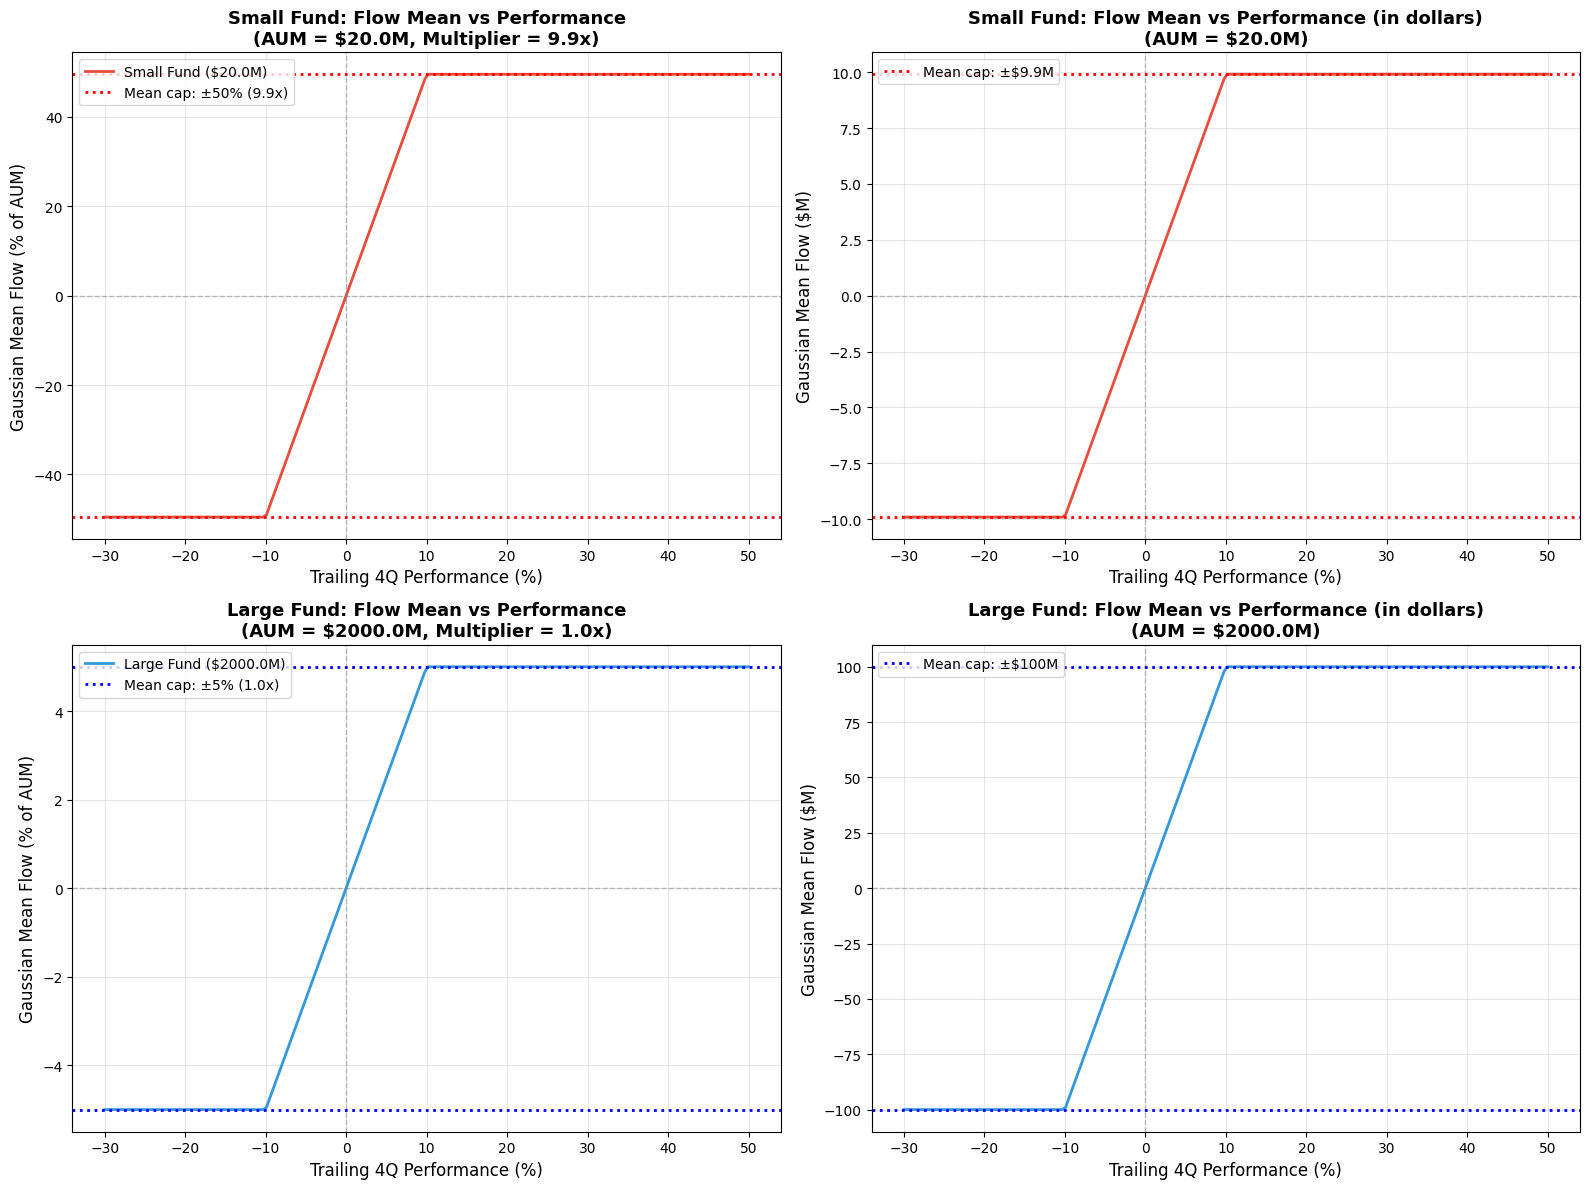


💡 Key Insights:
• Small fund ($20.0M): 9.9x multiplier → flow sensitivity ±50% of AUM
• Large fund ($2000.0M): 1.0x multiplier → flow sensitivity ±5% of AUM
• Small funds experience much more volatile flows as % of AUM
• Both maintain linear relationship: μ = α × R_4Q × multiplier × AUM


In [3]:
# Visualize the relationship for both scenarios
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: Small Fund ($20M)
small_multiplier = manager._calculate_aum_multiplier(SMALL_FUND_AUM)
small_mean_cap = IFP.MAX_MEAN_FLOW_PCT * small_multiplier

# Plot 1a: Small fund - Mean as % of AUM
axes[0, 0].plot(hypothetical_returns * 100, np.array(results_small['means_pct']) * 100, 
                linewidth=2, color='#e74c3c', label=f'Small Fund (${SMALL_FUND_AUM}M)')
axes[0, 0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].axhline(y=small_mean_cap * 100, color='red', linestyle=':', linewidth=2, 
                   label=f'Mean cap: ±{small_mean_cap*100:.0f}% ({small_multiplier:.1f}x)')
axes[0, 0].axhline(y=-small_mean_cap * 100, color='red', linestyle=':', linewidth=2)
axes[0, 0].set_xlabel('Trailing 4Q Performance (%)', fontsize=12)
axes[0, 0].set_ylabel('Gaussian Mean Flow (% of AUM)', fontsize=12)
axes[0, 0].set_title(f'Small Fund: Flow Mean vs Performance\n(AUM = ${SMALL_FUND_AUM}M, Multiplier = {small_multiplier:.1f}x)', 
                     fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=10)

# Plot 1b: Small fund - Mean in dollars
axes[0, 1].plot(hypothetical_returns * 100, results_small['means_dollars'], 
                linewidth=2, color='#e74c3c')
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
max_mean_dollars_small = small_mean_cap * SMALL_FUND_AUM
axes[0, 1].axhline(y=max_mean_dollars_small, color='red', linestyle=':', linewidth=2,
                   label=f'Mean cap: ±${max_mean_dollars_small:.1f}M')
axes[0, 1].axhline(y=-max_mean_dollars_small, color='red', linestyle=':', linewidth=2)
axes[0, 1].set_xlabel('Trailing 4Q Performance (%)', fontsize=12)
axes[0, 1].set_ylabel('Gaussian Mean Flow ($M)', fontsize=12)
axes[0, 1].set_title(f'Small Fund: Flow Mean vs Performance (in dollars)\n(AUM = ${SMALL_FUND_AUM}M)', 
                     fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(fontsize=10)

# Row 2: Large Fund ($2B)
large_multiplier = manager._calculate_aum_multiplier(LARGE_FUND_AUM)
large_mean_cap = IFP.MAX_MEAN_FLOW_PCT * large_multiplier

# Plot 2a: Large fund - Mean as % of AUM
axes[1, 0].plot(hypothetical_returns * 100, np.array(results_large['means_pct']) * 100, 
                linewidth=2, color='#3498db', label=f'Large Fund (${LARGE_FUND_AUM}M)')
axes[1, 0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].axhline(y=large_mean_cap * 100, color='blue', linestyle=':', linewidth=2,
                   label=f'Mean cap: ±{large_mean_cap*100:.0f}% ({large_multiplier:.1f}x)')
axes[1, 0].axhline(y=-large_mean_cap * 100, color='blue', linestyle=':', linewidth=2)
axes[1, 0].set_xlabel('Trailing 4Q Performance (%)', fontsize=12)
axes[1, 0].set_ylabel('Gaussian Mean Flow (% of AUM)', fontsize=12)
axes[1, 0].set_title(f'Large Fund: Flow Mean vs Performance\n(AUM = ${LARGE_FUND_AUM}M, Multiplier = {large_multiplier:.1f}x)', 
                     fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(fontsize=10)

# Plot 2b: Large fund - Mean in dollars
axes[1, 1].plot(hypothetical_returns * 100, results_large['means_dollars'], 
                linewidth=2, color='#3498db')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
max_mean_dollars_large = large_mean_cap * LARGE_FUND_AUM
axes[1, 1].axhline(y=max_mean_dollars_large, color='blue', linestyle=':', linewidth=2,
                   label=f'Mean cap: ±${max_mean_dollars_large:.0f}M')
axes[1, 1].axhline(y=-max_mean_dollars_large, color='blue', linestyle=':', linewidth=2)
axes[1, 1].set_xlabel('Trailing 4Q Performance (%)', fontsize=12)
axes[1, 1].set_ylabel('Gaussian Mean Flow ($M)', fontsize=12)
axes[1, 1].set_title(f'Large Fund: Flow Mean vs Performance (in dollars)\n(AUM = ${LARGE_FUND_AUM}M)', 
                     fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
print(f"• Small fund (${SMALL_FUND_AUM}M): {small_multiplier:.1f}x multiplier → flow sensitivity ±{small_mean_cap*100:.0f}% of AUM")
print(f"• Large fund (${LARGE_FUND_AUM}M): {large_multiplier:.1f}x multiplier → flow sensitivity ±{large_mean_cap*100:.0f}% of AUM")
print(f"• Small funds experience much more volatile flows as % of AUM")
print(f"• Both maintain linear relationship: μ = α × R_4Q × multiplier × AUM")

## Analysis 2: Flow Distribution Visualization

**Key Question:** What does the complete Gaussian distribution look like for different performance scenarios at different fund sizes?

This shows the full probability distribution of flows, including both mean (μ) and volatility (σ).

This analysis compares two scenarios:
- **Small Fund ($20M AUM):** Wider distribution range due to AUM multiplier
- **Large Fund ($2B AUM):** Narrower distribution range

The multiplier affects both the mean and the magnitude, creating significantly different flow dynamics.

In [4]:
# Select representative performance scenarios
scenarios = [
    {'name': 'Strong Performance', 'return': 0.30, 'color': '#27ae60'},
    {'name': 'Moderate Performance', 'return': 0.10, 'color': '#3498db'},
    {'name': 'Neutral Performance', 'return': 0.0, 'color': '#95a5a6'},
    {'name': 'Moderate Loss', 'return': -0.10, 'color': '#e67e22'},
    {'name': 'Large Loss', 'return': -0.30, 'color': '#e74c3c'}
]

# Calculate for both fund sizes
print(f"📊 Flow Distribution Scenarios")
print(f"="*90)
print(f"\nSmall Fund (${SMALL_FUND_AUM}M AUM):")
print(f"  Multiplier: {manager._calculate_aum_multiplier(SMALL_FUND_AUM):.2f}x")
print(f"{'-'*90}")
print(f"{'Scenario':<25} {'Return':<10} {'Mean μ':<18} {'Std σ':<15}")
print(f"{'-'*90}")

for scenario in scenarios:
    mean_pct, mean_dollars, std_pct, std_dollars, _ = manager._calculate_distribution_parameters(
        trailing_return=scenario['return'],
        current_aum=SMALL_FUND_AUM
    )
    scenario['small_mean_pct'] = mean_pct
    scenario['small_mean_dollars'] = mean_dollars
    scenario['small_std_pct'] = std_pct
    scenario['small_std_dollars'] = std_dollars
    
    print(f"{scenario['name']:<25} {scenario['return']:>8.1%}  "
          f"{mean_pct:>7.2%} (${mean_dollars:>6.2f}M)    {std_pct:>7.2%} AUM")

print(f"\n{'='*90}")
print(f"\nLarge Fund (${LARGE_FUND_AUM}M AUM):")
print(f"  Multiplier: {manager._calculate_aum_multiplier(LARGE_FUND_AUM):.2f}x")
print(f"{'-'*90}")
print(f"{'Scenario':<25} {'Return':<10} {'Mean μ':<20} {'Std σ':<15}")
print(f"{'-'*90}")

for scenario in scenarios:
    mean_pct, mean_dollars, std_pct, std_dollars, _ = manager._calculate_distribution_parameters(
        trailing_return=scenario['return'],
        current_aum=LARGE_FUND_AUM
    )
    scenario['large_mean_pct'] = mean_pct
    scenario['large_mean_dollars'] = mean_dollars
    scenario['large_std_pct'] = std_pct
    scenario['large_std_dollars'] = std_dollars
    
    print(f"{scenario['name']:<25} {scenario['return']:>8.1%}  "
          f"{mean_pct:>7.2%} (${mean_dollars:>7.0f}M)    {std_pct:>7.2%} AUM")

📊 Flow Distribution Scenarios

Small Fund ($20.0M AUM):
  Multiplier: 9.91x
------------------------------------------------------------------------------------------
Scenario                  Return     Mean μ             Std σ          
------------------------------------------------------------------------------------------
Strong Performance           30.0%   49.55% ($  9.91M)     10.00% AUM
Moderate Performance         10.0%   49.55% ($  9.91M)     10.00% AUM
Neutral Performance           0.0%    0.00% ($  0.00M)     10.00% AUM
Moderate Loss               -10.0%  -49.55% ($ -9.91M)     10.00% AUM
Large Loss                  -30.0%  -49.55% ($ -9.91M)     10.00% AUM


Large Fund ($2000.0M AUM):
  Multiplier: 1.00x
------------------------------------------------------------------------------------------
Scenario                  Return     Mean μ               Std σ          
------------------------------------------------------------------------------------------
Strong Performa

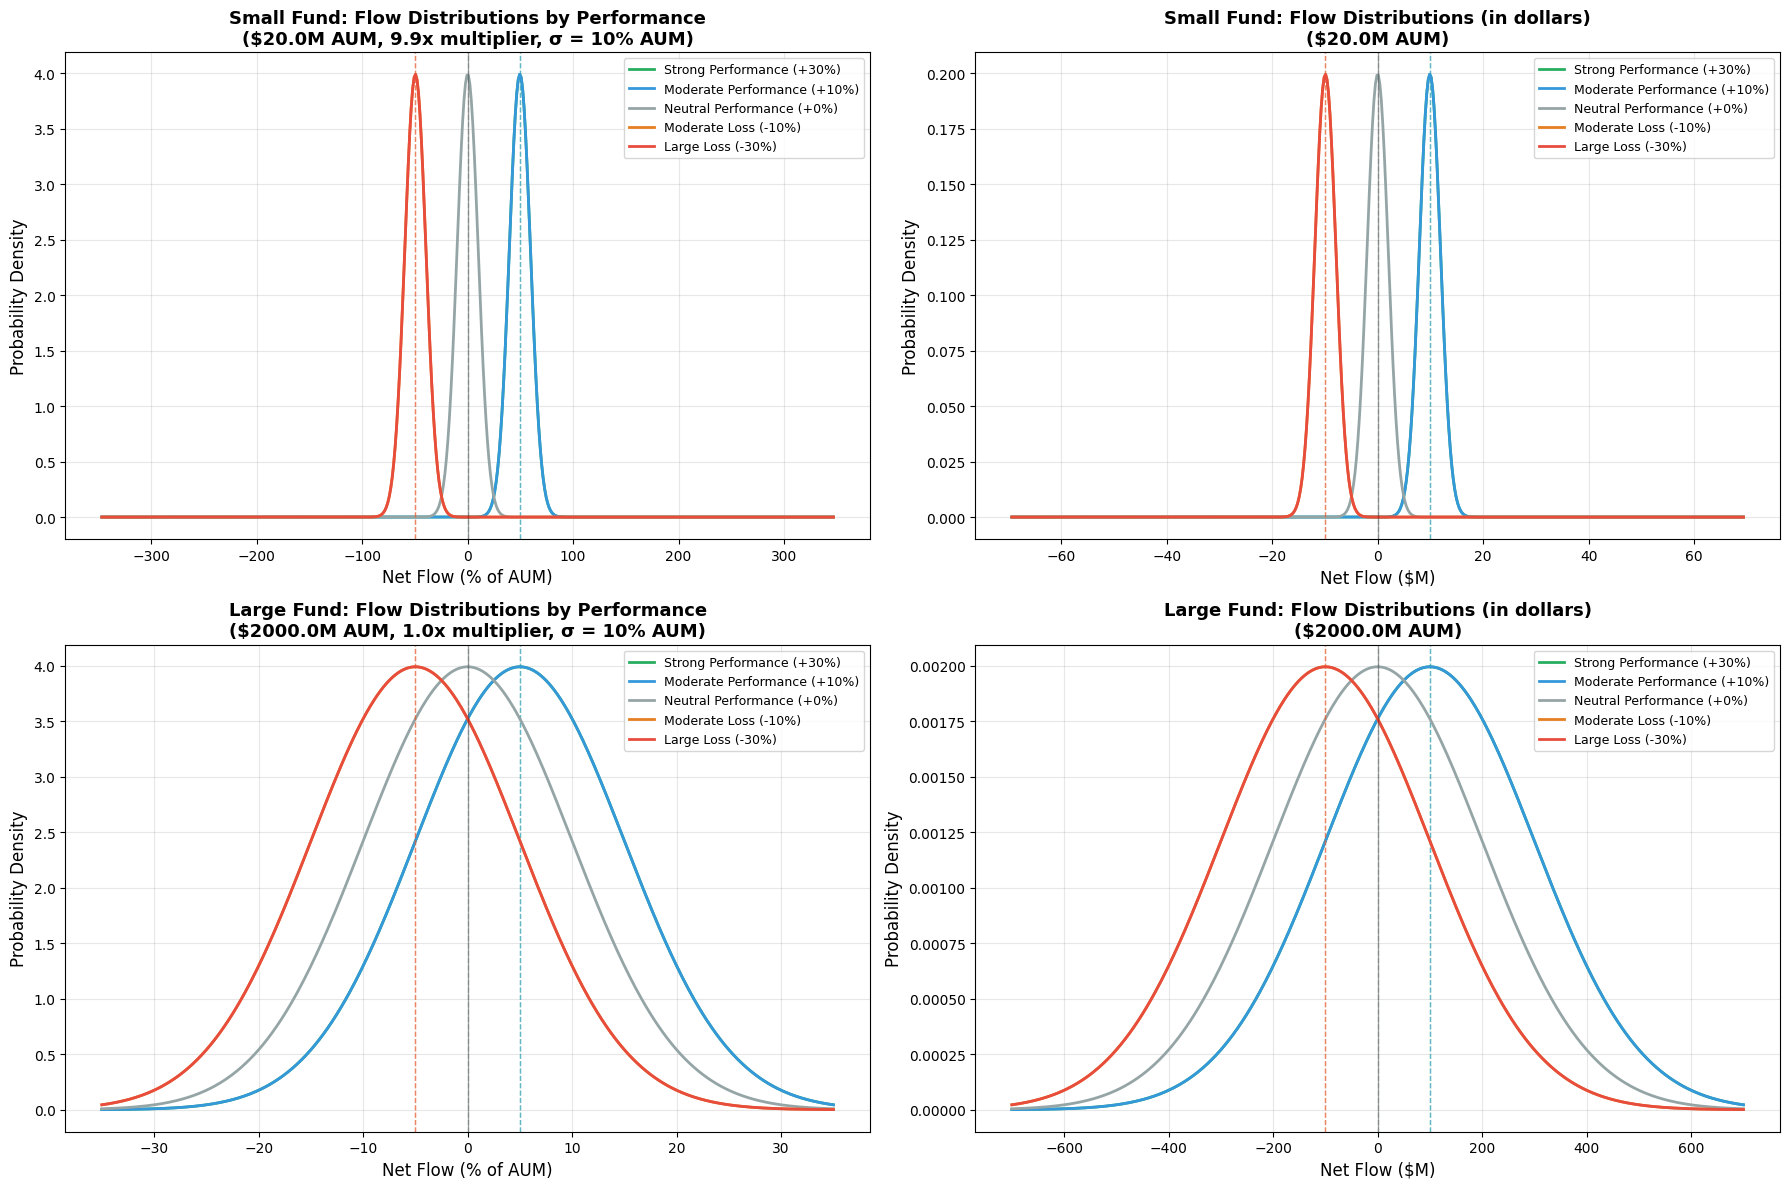


💡 Key Insights:
• Small fund ($20.0M): 9.9x multiplier → wider distributions (σ = 10% AUM)
• Large fund ($2000.0M): 1.0x multiplier → narrower distributions (σ = 10% AUM)
• Both have same base volatility, but multiplier scales the entire distribution
• Small funds have much more volatile flow dynamics relative to their size


In [5]:
# Create 2x2 grid: Small fund (row 1) vs Large fund (row 2)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ========== ROW 1: SMALL FUND ($20M) ==========

# Calculate appropriate x-range for small fund
small_multiplier = manager._calculate_aum_multiplier(SMALL_FUND_AUM)
small_max_mean = IFP.MAX_MEAN_FLOW_PCT * small_multiplier
small_max_std = IFP.FLOW_VOLATILITY_PCT * small_multiplier
x_range_small_pct = np.linspace(-small_max_mean - 3*small_max_std, 
                                 small_max_mean + 3*small_max_std, 500)

# Plot 1a: Small fund - Distributions as % of AUM
for scenario in scenarios:
    pdf = (1 / (scenario['small_std_pct'] * np.sqrt(2 * np.pi))) * \
          np.exp(-0.5 * ((x_range_small_pct - scenario['small_mean_pct']) / scenario['small_std_pct'])**2)
    
    axes[0, 0].plot(x_range_small_pct * 100, pdf, linewidth=2, 
                    label=f"{scenario['name']} ({scenario['return']:+.0%})",
                    color=scenario['color'])
    axes[0, 0].axvline(x=scenario['small_mean_pct'] * 100, color=scenario['color'], 
                       linestyle='--', linewidth=1, alpha=0.5)

axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 0].set_xlabel('Net Flow (% of AUM)', fontsize=12)
axes[0, 0].set_ylabel('Probability Density', fontsize=12)
axes[0, 0].set_title(f'Small Fund: Flow Distributions by Performance\n(${SMALL_FUND_AUM}M AUM, {small_multiplier:.1f}x multiplier, σ = {scenario["small_std_pct"]*100:.0f}% AUM)', 
                     fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=9, loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Plot 1b: Small fund - Distributions in dollars
x_range_small_dollars = x_range_small_pct * SMALL_FUND_AUM

for scenario in scenarios:
    pdf_dollars = (1 / (scenario['small_std_dollars'] * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_range_small_dollars - scenario['small_mean_dollars']) / scenario['small_std_dollars'])**2)
    
    axes[0, 1].plot(x_range_small_dollars, pdf_dollars, linewidth=2,
                    label=f"{scenario['name']} ({scenario['return']:+.0%})",
                    color=scenario['color'])
    axes[0, 1].axvline(x=scenario['small_mean_dollars'], color=scenario['color'],
                       linestyle='--', linewidth=1, alpha=0.5)

axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 1].set_xlabel('Net Flow ($M)', fontsize=12)
axes[0, 1].set_ylabel('Probability Density', fontsize=12)
axes[0, 1].set_title(f'Small Fund: Flow Distributions (in dollars)\n(${SMALL_FUND_AUM}M AUM)', 
                     fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=9, loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# ========== ROW 2: LARGE FUND ($2B) ==========

# Calculate appropriate x-range for large fund
large_multiplier = manager._calculate_aum_multiplier(LARGE_FUND_AUM)
large_max_mean = IFP.MAX_MEAN_FLOW_PCT * large_multiplier
large_max_std = IFP.FLOW_VOLATILITY_PCT * large_multiplier
x_range_large_pct = np.linspace(-large_max_mean - 3*large_max_std, 
                                 large_max_mean + 3*large_max_std, 500)

# Plot 2a: Large fund - Distributions as % of AUM
for scenario in scenarios:
    pdf = (1 / (scenario['large_std_pct'] * np.sqrt(2 * np.pi))) * \
          np.exp(-0.5 * ((x_range_large_pct - scenario['large_mean_pct']) / scenario['large_std_pct'])**2)
    
    axes[1, 0].plot(x_range_large_pct * 100, pdf, linewidth=2, 
                    label=f"{scenario['name']} ({scenario['return']:+.0%})",
                    color=scenario['color'])
    axes[1, 0].axvline(x=scenario['large_mean_pct'] * 100, color=scenario['color'], 
                       linestyle='--', linewidth=1, alpha=0.5)

axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[1, 0].set_xlabel('Net Flow (% of AUM)', fontsize=12)
axes[1, 0].set_ylabel('Probability Density', fontsize=12)
axes[1, 0].set_title(f'Large Fund: Flow Distributions by Performance\n(${LARGE_FUND_AUM}M AUM, {large_multiplier:.1f}x multiplier, σ = {scenario["large_std_pct"]*100:.0f}% AUM)', 
                     fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=9, loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# Plot 2b: Large fund - Distributions in dollars
x_range_large_dollars = x_range_large_pct * LARGE_FUND_AUM

for scenario in scenarios:
    pdf_dollars = (1 / (scenario['large_std_dollars'] * np.sqrt(2 * np.pi))) * \
                  np.exp(-0.5 * ((x_range_large_dollars - scenario['large_mean_dollars']) / scenario['large_std_dollars'])**2)
    
    axes[1, 1].plot(x_range_large_dollars, pdf_dollars, linewidth=2,
                    label=f"{scenario['name']} ({scenario['return']:+.0%})",
                    color=scenario['color'])
    axes[1, 1].axvline(x=scenario['large_mean_dollars'], color=scenario['color'],
                       linestyle='--', linewidth=1, alpha=0.5)

axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[1, 1].set_xlabel('Net Flow ($M)', fontsize=12)
axes[1, 1].set_ylabel('Probability Density', fontsize=12)
axes[1, 1].set_title(f'Large Fund: Flow Distributions (in dollars)\n(${LARGE_FUND_AUM}M AUM)', 
                     fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9, loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Key Insights:")
print(f"• Small fund (${SMALL_FUND_AUM}M): {small_multiplier:.1f}x multiplier → wider distributions (σ = {scenario['small_std_pct']*100:.0f}% AUM)")
print(f"• Large fund (${LARGE_FUND_AUM}M): {large_multiplier:.1f}x multiplier → narrower distributions (σ = {scenario['large_std_pct']*100:.0f}% AUM)")
print(f"• Both have same base volatility, but multiplier scales the entire distribution")
print(f"• Small funds have much more volatile flow dynamics relative to their size")